# Overview

## Spectra Analysis: Paint and Non-Paint Microplastic Classification
Welcome to the Spectra Analysis Jupyter Notebook, an interactive component of the research project accompanying the forthcoming paper: "A Paint Library Of Plastic Particles (PLOPP): Fourier Transform Infrared Spectral Analysis of Paint Microplastics" by Zoie T. Diana, Madeleine Milne, Jacob Ford, Ron Rubinovitz, Andrew Turner, and Chelsea M. Rochman.

This notebook supports the study's objective of developing a comprehensive FTIR-based paint library and enhancing environmental microplastic identification. By leveraging the Paint Library of Plastic Products (PLOPP), which houses spectra from various paint types, this project seeks to improve microplastic classification in environmental samples.

## Notebook Overview
The purpose of this notebook is to guide users through the ML pipeline developed to classify Fourier transform infrared (FTIR) spectra as either paint or non-paint microplastics, with an emphasis on:

- Data Preprocessing: Steps for preparing and transforming spectral data.
- Model Training and Selection: Implementation of a Gradient Boosting Classifier optimized for spectral data classification.
- Evaluation and Prediction: Assessing model accuracy and applying the classifier to real-world samples.

## Project Scope
The broader goal is to enable researchers and environmental scientists to use PLOPP for identifying paint microplastics among environmental samples, with initial tests focused on samples from the River Thames, United Kingdom. This notebook allows users to replicate our machine learning analysis and customize it for further exploration or validation.


In [61]:
# Import necessary libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
import json
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report, 
                             roc_curve, auc)
from matplotlib.ticker import MaxNLocator
import shap


from xgboost import XGBClassifier


pd.options.display.float_format = '{:.6f}'.format


# pd.set_option('display.max_columns', None)


# 1. Load Data and Preprocess

## PLoPP

In [62]:
# Combine all the CSVs into one merged PLOPP dataset

def process_csv_files(directory):
    data_frames = []

    for filename in os.listdir(directory):
        if filename.lower().endswith('.csv'):  
            file_path = os.path.join(directory, filename) 

            df = pd.read_csv(file_path, header=None, names=['Wavelength', 'Datavalue'])
            df_transposed = df.set_index('Wavelength').T
            df_transposed['Sample'] = filename

            data_frames.append(df_transposed)

    master_df = pd.concat(data_frames, axis=0).fillna(0)

    return master_df

directory = "../../../../CSV Files/PLOPP/CSV Files"


plopp_df = process_csv_files(directory)

#plopp_df.columns = ['wavelength_' + str(col) if col not in ['Sample'] else col for col in plopp_df.columns]
plopp_df.columns = [int(col) if col not in ['Sample', 'Target', 'Wavelength'] else col for col in plopp_df.columns]


plopp_df['Target'] = "PLoPP"

# plopp_df.to_csv("../../../../CSV Files/PLOPP/plopp_merged.csv", index=False)



# Print the master DataFrame for review
print(plopp_df.shape)

plopp_df



(263, 938)


,397,401,404,408,412,416,420,424,428,431,...,3976,3980,3984,3988,3992,3995,3999,4003,Sample,Target
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,91.817920,91.799890,91.768400,91.759260,91.803400,91.885330,91.895230,0.000000,54c.CSV,PLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,97.245870,97.219830,97.283520,97.345570,97.343240,97.352390,97.383830,0.000000,23a.CSV,PLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,91.535050,91.539890,91.538020,91.560490,91.593530,91.580960,91.587860,0.000000,74a.CSV,PLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,92.119210,92.109000,92.050710,92.068950,92.132290,92.172480,92.242130,0.000000,78b.CSV,PLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,94.578730,94.567590,94.558040,94.586940,94.629390,94.671810,94.684270,0.000000,9a.CSV,PLoPP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,96.000130,96.019650,95.995780,95.956410,95.981160,96.036570,96.074420,0.000000,41b.CSV,PLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,100.101600,100.126900,100.160900,100.165200,100.168700,100.168900,100.157700,0.000000,82c.CSV,PLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,91.348060,91.368650,91.401120,91.413200,91.408660,91.441210,91.456630,0.000000,6c.CSV,PLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,93.008270,92.958400,92.905300,92.870000,92.903980,92.938250,92.967780,0.000000,16b.CSV,PLoPP



## FLoPP

In [63]:
directory = "../../../../CSV Files/FLOPP/8 cm -1 resolution CORRECT"

flopp_df = process_csv_files(directory)
#flopp_df.columns = ['wavelength_' + str(col) if col not in ['Sample'] else col for col in flopp_df.columns]
flopp_df.columns = [int(col) if col not in ['Sample'] else col for col in flopp_df.columns]


flopp_df['Target'] = "FLoPP"

#flopp_df.to_csv("../../CSV Files/FLOPP/Flopp_merged.csv", index=False)


print(flopp_df.shape)
# Print the master DataFrame for review
flopp_df

flopps_cols = flopp_df.columns
plopp_cols = plopp_df.columns

# print out the column elements

merged_cols = [i for i in plopp_cols if i in flopps_cols]


(186, 938)


In [64]:
import re

result_df = pd.concat([flopp_df, plopp_df], axis=0, ignore_index=True)

def extract_integer_prefix(sample_name):
    match = re.match(r'^(\d+)', sample_name)
    return match.group(1) if match else None

# Apply the function to create a 'Group' column
result_df['Group'] = result_df['Sample'].apply(extract_integer_prefix)

result_df

#result_df.to_csv("../../data/output/merged_df.csv")

,397,401,404,408,412,416,420,424,428,431,...,3980,3984,3988,3992,3995,3999,4003,Sample,Target,Group
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.064640,98.072340,98.090140,98.065730,98.030320,98.040350,0.000000,PE 12_8cm.CSV,FLoPP,None
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.516020,98.449390,98.543720,98.516090,98.505090,98.499170,0.000000,ABS12_8cm.CSV,FLoPP,None
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,104.303800,104.309200,104.332100,104.467600,104.351000,104.341500,0.000000,Nylon 5_8cm.CSV,FLoPP,None
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,101.123400,101.041400,101.108400,101.113200,101.091900,101.109900,0.000000,PET 2_8cm.CSV,FLoPP,None
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,99.043970,98.959140,98.883790,98.834790,99.027960,99.004300,0.000000,Acrylic5_8cm.CSV,FLoPP,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,96.019650,95.995780,95.956410,95.981160,96.036570,96.074420,0.000000,41b.CSV,PLoPP,41
445,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,100.126900,100.160900,100.165200,100.168700,100.168900,100.157700,0.000000,82c.CSV,PLoPP,82
446,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,91.368650,91.401120,91.413200,91.408660,91.441210,91.456630,0.000000,6c.CSV,PLoPP,6
447,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,92.958400,92.905300,92.870000,92.903980,92.938250,92.967780,0.000000,16b.CSV,PLoPP,16


# 2. Hyperparam tuning

In [65]:
# Separate the data into PLOPP and FLOPP based on the 'Group' column
plopp_df = result_df[result_df['Target'] != 'FLoPP']
flopp_df = result_df[result_df['Target'] == 'FLoPP']

# Step 1: Group by 'Group' and split the PLOPP data
plopp_train_groups, plopp_test_groups = train_test_split(plopp_df['Group'].unique(), test_size=0.4, random_state=42)

plopp_train_df = plopp_df[plopp_df['Group'].isin(plopp_train_groups)]
plopp_test_df = plopp_df[plopp_df['Group'].isin(plopp_test_groups)]

# Step 2: Perform regular train-test split for FLOPP
flopp_train_df, flopp_test_df = train_test_split(flopp_df, test_size=0.4, random_state=42)

# Step 3: Combine the train and test datasets
train_df = pd.concat([plopp_train_df, flopp_train_df])
test_df = pd.concat([plopp_test_df, flopp_test_df])

X_train = train_df.drop(['Target', 'Sample', 'Group'], axis=1)
y_train = train_df['Target']

X_test = test_df.drop(['Target', 'Sample', 'Group'], axis=1)
y_test = test_df['Target']




In [66]:
y_test.value_counts()

Target
PLoPP    106
FLoPP     75
Name: count, dtype: int64

In [67]:

def standard_normal_variate(X):
    mean_centered = X - np.mean(X, axis=1, keepdims=True)
    snv_transformed = mean_centered / np.std(mean_centered, axis=1, keepdims=True)
    return snv_transformed

def calculate_derivatives(data, window_length, polyorder, deriv=1):
    return savgol_filter(data, window_length, polyorder, deriv=deriv)

class SNVTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, use_scaling=True):
        self.use_scaling = use_scaling

    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = np.array(X)
        mean_centered = X - np.mean(X, axis=1, keepdims=True)
        if self.use_scaling:
            return mean_centered / np.std(mean_centered, axis=1, keepdims=True)
        return mean_centered

class DerivativeTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, window_length=11, polyorder=2, deriv=1):
        self.window_length = window_length
        self.polyorder = polyorder
        self.deriv = deriv
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = np.array(X)
        transformed = np.apply_along_axis(calculate_derivatives, axis=1, arr=X,
                                          window_length=self.window_length, 
                                          polyorder=self.polyorder, deriv=self.deriv)
        return transformed


In [68]:
# # Remove rows where 'Target' has NaN values
# result_df = result_df.dropna(subset=['Target'])

# # Map 'Target' to binary values and split features and target
# result_df['Target'] = result_df['Target'].map({'FLoPP': 0, 'PLoPP': 1})

# # Convert categorical columns in `features` to numeric (one-hot encoding)
# features = result_df.drop(['Target', 'Sample', 'Group'], axis=1)
# features = pd.get_dummies(features)  # Ensures all columns are numeric

# target = result_df['Target']

# # Split the data
# X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.4, random_state=42)

# print('Training data shape:', X_train.shape)
# print('Testing data shape:', X_test.shape)
# # Models to be evaluated
# models = {
#     'Random Forest': RandomForestClassifier(),
#     'Logistic Regression': LogisticRegression(max_iter=1000),
#     'SVM': SVC(probability=True),
#     'XGBoost': XGBClassifier()
# }

# best_model_name = None
# best_f1_score = 0
# best_params = {}

# for name, model in models.items():
#     plopp_pipeline = Pipeline([
#         ('snv', SNVTransformer()),
#         ('derivatives', DerivativeTransformer()),
#         ('classifier', model)
#     ])
    
#     param_grid = {
#         'snv__use_scaling': [True, False],
#         'derivatives__deriv': [0, 1, 2]
#     }

#     if name == 'XGBoost':
#         param_grid.update({
#             'classifier__n_estimators': [100, 500],
#             'classifier__learning_rate': [0.01, 0.05, 0.1],
#             'classifier__max_depth': [3, 6, 9]
#         })

#     if name == "Random Forest":
#         param_grid.update({
#             'classifier__n_estimators': [100, 200, 300, 500],
#             'classifier__max_depth': [3, 6, 9],
#             'classifier__min_samples_split': [2, 5, 10],
#             'classifier__min_samples_leaf': [1, 2, 4],
#             'classifier__max_features': ['auto', 'sqrt', 'log2']
#         })

#     if name == "Logistic Regression":
#         param_grid.update({
#             'classifier__penalty': ['l1', 'l2', 'elasticnet', 'none'],
#             'classifier__C': [0.01, 0.1, 1, 10, 100],
#             'classifier__solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
#         })

#     if name == "SVM":
#         param_grid.update({
#             'classifier__C': [0.1, 1, 10, 100],
#             'classifier__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
#             'classifier__gamma': ['scale', 'auto']
#         })

#     grid_search = GridSearchCV(plopp_pipeline, param_grid, cv=5, scoring='f1', verbose=1)
    
#     grid_search.fit(X_train, y_train)
    
#     print(f"Best parameters for {name}:", grid_search.best_params_)
#     print(f"Best cross-validation score (F1) for {name}: {grid_search.best_score_:.3f}")
    
#     if grid_search.best_score_ > best_f1_score:
#         best_f1_score = grid_search.best_score_
#         best_model_name = name
#         best_params = grid_search.best_params_

# with open('best_params.json', 'w') as f:
#     json.dump(best_params, f)

# print(f"The best model is {best_model_name} with a cross-validation F1 score of {best_f1_score:.3f}")


In [69]:
# with open ('best_params.json') as f:
#     best_params = json.load(f)

# print(f"Best parameters: {best_params}")

best_params = {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'derivatives__deriv': 1, 'snv__use_scaling': True}

best_params

{'classifier__learning_rate': 0.1,
 'classifier__max_depth': 3,
 'classifier__n_estimators': 100,
 'derivatives__deriv': 1,
 'snv__use_scaling': True}

# 3. Final Model Training

In [70]:
# Create the pipeline with PCA included
plopp_pipeline = Pipeline([
    ('snv', SNVTransformer(use_scaling=True)),                # Apply SNV transformation
    ('derivative', DerivativeTransformer(deriv=1)),           # Apply derivative transformation
    ('pca', PCA(n_components=0.95)),                          # Apply PCA to retain 95% variance
    ('classifier', RandomForestClassifier(random_state=42))   # A RandomForest model
])

# Drop 'Group' from X_train before fitting the pipeline
plopp_pipeline.fit(X_train, y_train)

# Extract the PCA step from the pipeline
pca = plopp_pipeline.named_steps['pca']

# Calculate the cumulative variance explained by the components
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Find the number of components that explain at least 95% of the variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Number of components that account for 95% of the variance: {n_components_95}")
print("Cumulative variance explained by each component:")

# Print the cumulative variance and top contributing features for each component
for i, cumulative_var in enumerate(cumulative_variance):
    if i < n_components_95:  # Only print for components up to 95% variance
        print(f"\nComponent {i+1} (Cumulative Variance: {cumulative_var:.4f}):")
        # Get the top contributing features for this component
        component = pca.components_[i]
        feature_importance = pd.Series(component, index=X_train.columns)
        top_features = feature_importance.abs().sort_values(ascending=False).head(10)
        for feature, importance in top_features.items():
            print(f"  Feature: {feature}, Importance: {importance:.4f}")

# Drop 'Group' from X_test before making predictions
#X_test = X_test.drop(columns=['Group'])

# Predict probabilities for each class
y_pred_proba = plopp_pipeline.predict_proba(X_test)


# Apply a cutoff of 0.60 for the positive class ('PLoPP')
y_pred = np.where(y_pred_proba[:, 1] >= 0.60, 'PLoPP', 'FLoPP')

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='PLoPP')
recall = recall_score(y_test, y_pred, pos_label='PLoPP')
f1 = f1_score(y_test, y_pred, pos_label='PLoPP')

# Print evaluation metrics
print(f"\nRandom Forest Model Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Number of components that account for 95% of the variance: 16
Cumulative variance explained by each component:

Component 1 (Cumulative Variance: 0.3250):
  Feature: 1735, Importance: 0.1841
  Feature: 1739, Importance: 0.1833
  Feature: 1743, Importance: 0.1714
  Feature: 740, Importance: 0.1705
  Feature: 1731, Importance: 0.1640
  Feature: 1700, Importance: 0.1590
  Feature: 736, Importance: 0.1581
  Feature: 1704, Importance: 0.1577
  Feature: 1747, Importance: 0.1515
  Feature: 1226, Importance: 0.1513

Component 2 (Cumulative Variance: 0.4910):
  Feature: 1747, Importance: 0.2290
  Feature: 1751, Importance: 0.2238
  Feature: 1743, Importance: 0.2037
  Feature: 1754, Importance: 0.1943
  Feature: 1720, Importance: 0.1780
  Feature: 1716, Importance: 0.1761
  Feature: 674, Importance: 0.1701
  Feature: 671, Importance: 0.1695
  Feature: 667, Importance: 0.1590
  Feature: 678, Importance: 0.1582

Component 3 (Cumulative Variance: 0.5656):
  Feature: 1735, Importance: 0.1719
  Featu

## Graphs and Figures

Total number of false positives: 6
Total number of false negatives: 5
Total Accuracy: 0.94
True Positive Rate: 0.95
False Positive Rate: 0.08
True Negative Rate: 0.92
False Negative Rate: 0.05


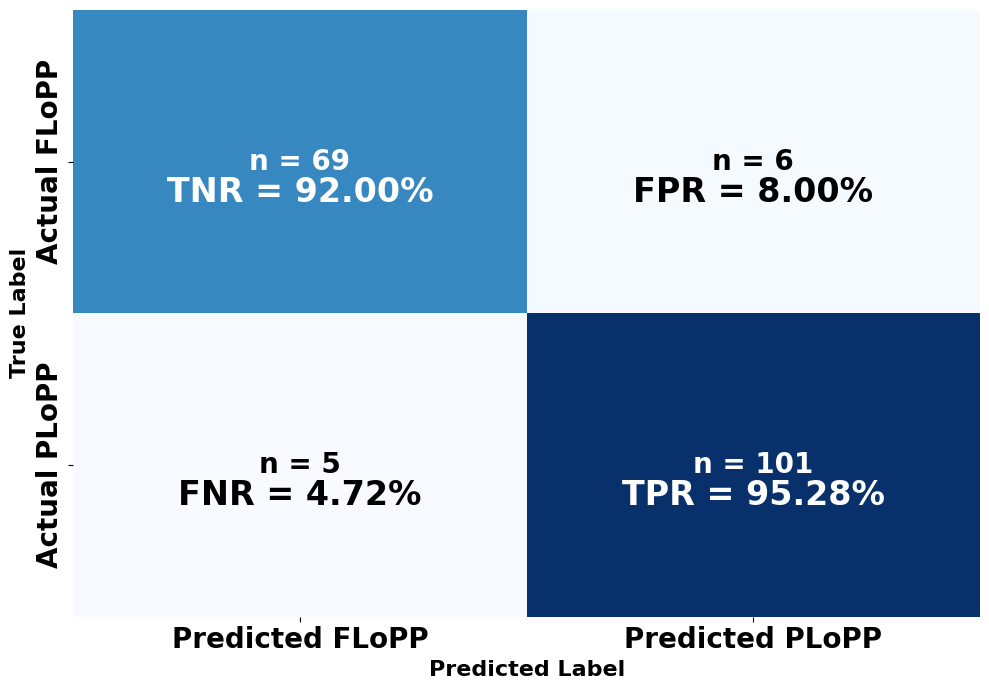

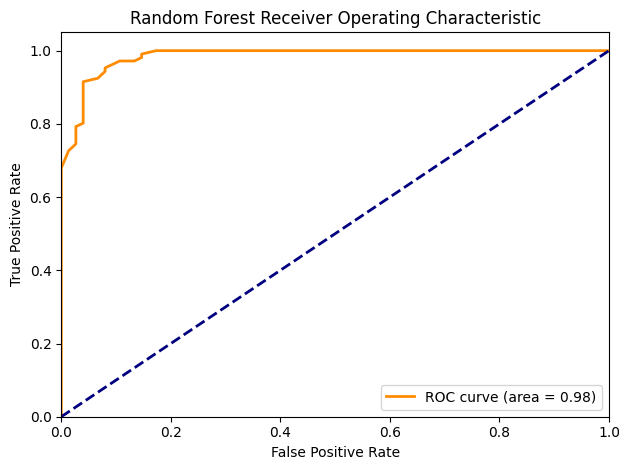

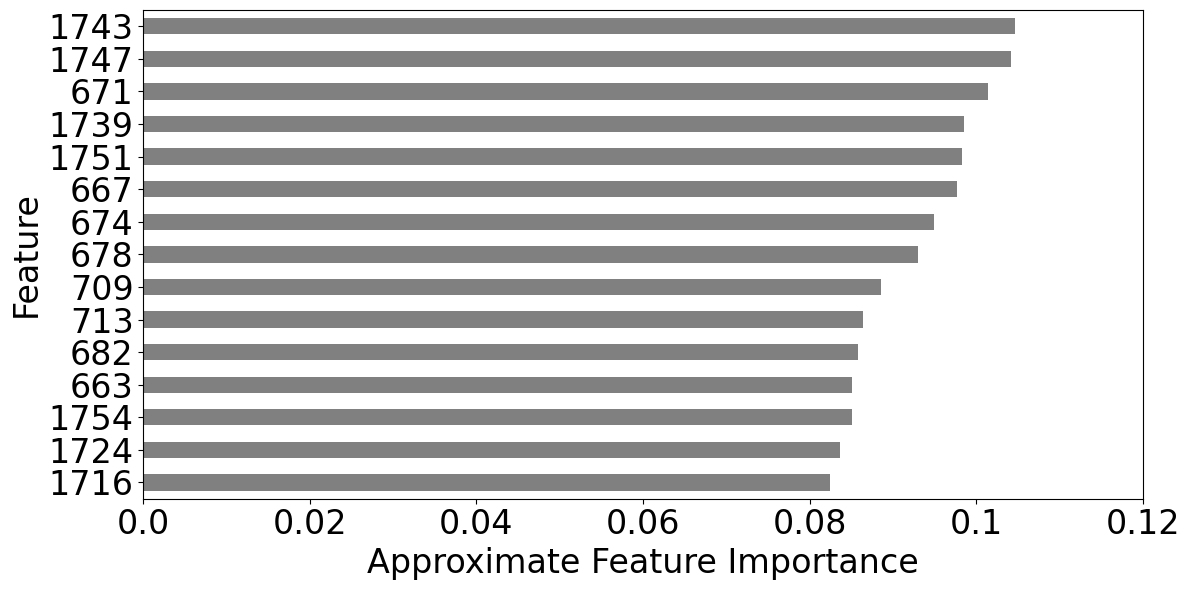

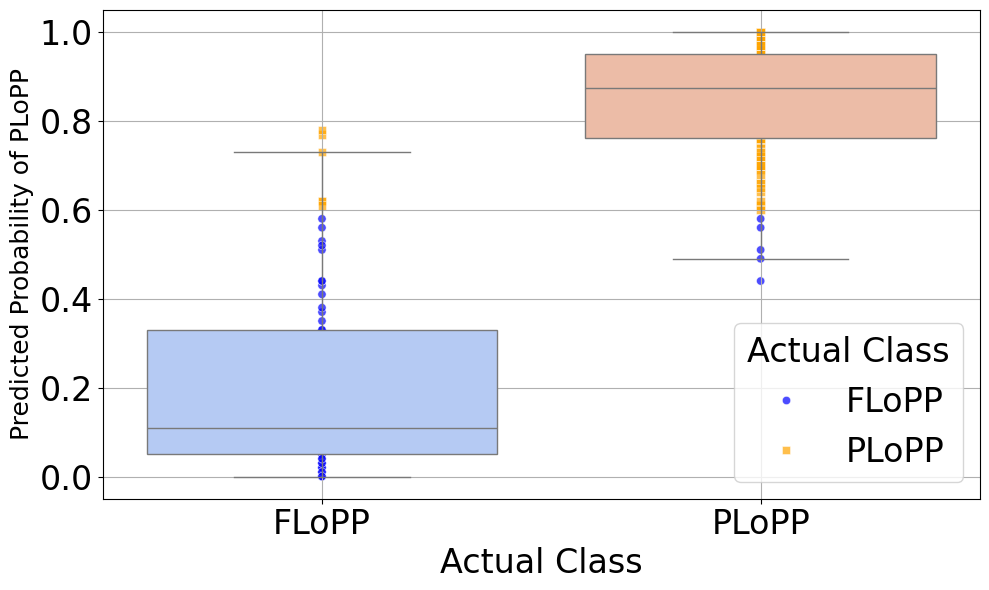

In [71]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Calculate additional metrics
total_accuracy = (tp + tn) / (tp + tn + fp + fn)
tpr = tp / (tp + fn)
fpr = fp / (fp + tn)
tnr = tn / (tn + fp)
fnr = fn / (fn + tp)

print(f'Total number of false positives: {fp}')
print(f'Total number of false negatives: {fn}')


print(f'Total Accuracy: {total_accuracy:.2f}')
print(f'True Positive Rate: {tpr:.2f}')
print(f'False Positive Rate: {fpr:.2f}')
print(f'True Negative Rate: {tnr:.2f}')
print(f'False Negative Rate: {fnr:.2f}')

# Creating a DataFrame for Confusion Matrix for better visualization
confusion_df = pd.DataFrame(cm, index=['Actual FLoPP', 'Actual PLoPP'], columns=['Predicted FLoPP', 'Predicted PLoPP'])

# Plotting the confusion matrix heatmap
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(confusion_df, annot=False, fmt='d', cmap='Blues', cbar=False, ax=ax)  # Set annot=True to show numbers
#ax.set_title('Random Forest Confusion Matrix')
ax.set_xlabel('Predicted Label', fontsize=16, weight='bold')
ax.set_ylabel('True Label', fontsize=16, weight='bold')
ax.set_xticklabels(ax.get_xticklabels(), fontsize=20, weight='bold')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=20, weight='bold')

# Annotate confusion matrix with TPR, FPR, etc.
for i in range(2):
    for j in range(2):
        color = 'white' if (i == 0 and j == 0) or (i == 1 and j == 1) else 'black'
        plt.text(j + 0.5, i + 0.5, f'n = {cm[i, j]}', ha='center', va='center', color=color, fontsize=20, weight='bold')

plt.text(0.5, 0.6, f'TNR = {tnr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold', color='white')
plt.text(1.5, 0.6, f'FPR = {fpr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold')
plt.text(.5, 1.6, f'FNR = {fnr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold')
plt.text(1.5, 1.6, f'TPR = {tpr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold', color='white')
plt.tight_layout()
#save this plot to a folder:
plt.savefig('../../../../Manuscript/Figures/Figure 4 Confusion matrix and box and whisker/Figure4_confusion_matrix.png')

plt.show()

# ROC Curve
y_prob = plopp_pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label='PLoPP')
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots()
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:0.2f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Random Forest Receiver Operating Characteristic')
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig('../../../../Manuscript/Figures/Figure 4 Confusion matrix and box and whisker/Figure_ROC_curve.png')

plt.show()

# Access the PCA and classifier from the pipeline
pca = plopp_pipeline.named_steps['pca']
classifier = plopp_pipeline.named_steps['classifier']

# Get the importance of the components from the classifier
component_importances = classifier.feature_importances_

# Get the original feature names and the PCA components
original_feature_names = X_train.columns
pca_components = pca.components_

# Calculate the approximate importance of the original features
approx_feature_importances = np.zeros(len(original_feature_names))

for i, component_importance in enumerate(component_importances):
    approx_feature_importances += component_importance * np.abs(pca_components[i])

# Create a series with the approximate importances
approx_importances_series = pd.Series(approx_feature_importances, index=original_feature_names)

# Sort and get the top 15 most important features
top_importances = approx_importances_series.sort_values(ascending=True)[-15:]

# Plot the feature importances
fig, ax = plt.subplots(figsize=(12, 6))
top_importances.plot(kind='barh', ax=ax, color='grey')

# Customize the plot with larger font sizes
ax.set_ylabel("Feature", fontsize=24)
ax.set_xlabel("Approximate Feature Importance", fontsize=24)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticks(), fontsize=24)
ax.set_yticklabels(top_importances.index, fontsize=24)
plt.tight_layout()
plt.savefig('../../../../Manuscript/Figures/Figure 4 Confusion matrix and box and whisker/Figure_Estimated_Feature_Importance.png')


plt.show()


# Predicted Probabilities Plot
plot_data = pd.DataFrame({
    'Predicted Probability': y_prob,
    'Predicted Class': y_pred,
    'Actual Class': y_test
})

# Convert 'Actual Class' to a categorical type and rename categories
plot_data['Actual Class'] = pd.Categorical(plot_data['Actual Class'])
plot_data['Actual Class'] = plot_data['Actual Class'].cat.rename_categories({0: 'FLoPP', 1: 'PLoPP'})
plot_data['Predicted Class'] = pd.Categorical(plot_data['Predicted Class'])
plot_data['Predicted Class'] = plot_data['Predicted Class'].cat.rename_categories({0: 'FLoPP', 1: 'PLoPP'})

plt.figure(figsize=(10, 6))

# Create a scatter plot with custom colors for Predicted Class
sns.scatterplot(
    data=plot_data, 
    y='Predicted Probability', 
    x='Actual Class',  
    hue='Predicted Class',  # Color by Predicted Class
    style='Predicted Class', 
    palette={'FLoPP': 'blue', 'PLoPP': 'orange'},  # Custom palette
    markers=['o', 's'], 
    alpha=0.7
)

# Create a horizontal boxplot overlay
sns.boxplot(
    data=plot_data, 
    y='Predicted Probability', 
    x='Actual Class', 
    hue='Actual Class', 
    palette='coolwarm',  # Original color palette for Actual Class
    whis=1.5, 
    fliersize=0
)

# Customize the plot with larger font sizes
plt.ylabel('Predicted Probability of PLoPP', fontsize=18)
plt.xlabel('Actual Class', fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.grid(True)

# Adjust legend to show both hue and style with larger font size
plt.legend(title='Actual Class', loc='lower right', fontsize=24, title_fontsize=24)

# Adjust layout to prevent clipping
plt.tight_layout()  # Ensures everything fits without being cut off

# Save the plot
plt.savefig('../../../../Manuscript/Figures/Figure 4 Confusion matrix and box and whisker/Figure_box_and_whiskers.png')

plt.show()


In [72]:
print("Overall Model Stats")

# Max, Min, and Mean values of the predicted probabilities, rounded to 2 decimal places
print(f"Max Predicted Probability: {plot_data['Predicted Probability'].max():.2f}")
print(f"Min Predicted Probability: {plot_data['Predicted Probability'].min():.2f}")
print(f"Mean Predicted Probability: {plot_data['Predicted Probability'].mean():.2f}")

print("----------")
print("PLoPP Stats")

# Stats for when Predicted Class = 'PLoPP', rounded to 2 decimal places
print(f"Max Predicted Probability: {plot_data[plot_data['Predicted Class'] == 'PLoPP']['Predicted Probability'].max():.2f}")
print(f"Min Predicted Probability: {plot_data[plot_data['Predicted Class'] == 'PLoPP']['Predicted Probability'].min():.2f}")
print(f"Mean Predicted Probability: {plot_data[plot_data['Predicted Class'] == 'PLoPP']['Predicted Probability'].mean():.2f}")

print("----------")
print("FLoPP Stats")

# Stats for when Predicted Class = 'FLoPP', rounded to 2 decimal places
print(f"Max Predicted Probability: {plot_data[plot_data['Predicted Class'] == 'FLoPP']['Predicted Probability'].max():.2f}")
print(f"Min Predicted Probability: {plot_data[plot_data['Predicted Class'] == 'FLoPP']['Predicted Probability'].min():.2f}")
print(f"Mean Predicted Probability: {plot_data[plot_data['Predicted Class'] == 'FLoPP']['Predicted Probability'].mean():.2f}")


Overall Model Stats
Max Predicted Probability: 1.00
Min Predicted Probability: 0.00
Mean Predicted Probability: 0.57
----------
PLoPP Stats
Max Predicted Probability: 1.00
Min Predicted Probability: 0.60
Mean Predicted Probability: 0.85
----------
FLoPP Stats
Max Predicted Probability: 0.58
Min Predicted Probability: 0.00
Mean Predicted Probability: 0.18


# 4. Paint by Sector

In [73]:
train_df.head()

,397,401,404,408,412,416,420,424,428,431,...,3980,3984,3988,3992,3995,3999,4003,Sample,Target,Group
187,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,97.219830,97.283520,97.345570,97.343240,97.352390,97.383830,0.000000,23a.CSV,PLoPP,23
188,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,91.539890,91.538020,91.560490,91.593530,91.580960,91.587860,0.000000,74a.CSV,PLoPP,74
189,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,92.109000,92.050710,92.068950,92.132290,92.172480,92.242130,0.000000,78b.CSV,PLoPP,78
192,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.836830,98.852810,98.843320,98.820400,98.824940,98.892400,0.000000,62a.CSV,PLoPP,62
193,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,92.619170,92.661870,92.692000,92.689920,92.728150,92.777500,0.000000,5b.CSV,PLoPP,5


In [74]:
train_df.Target.value_counts()

Target
PLoPP    157
FLoPP    111
Name: count, dtype: int64

In [75]:
train_df = pd.read_csv("../../data/output/merged_df.csv")

train_df = train_df[train_df['Target'] == 'PLoPP']

#train_df['Sample'] = train_df['Sample'].str.replace('.CSV', '')


train_df.drop(columns=['Unnamed: 0'], inplace=True)

train_df.head()

add_sector_df = pd.read_csv("../../data/merged_df_sector_color.csv")

print(add_sector_df.shape)

cols_to_kepp = ['CSVName', 'Sample', 'Sample_Number', 'Color', 'Sector']


add_sector_df = add_sector_df[cols_to_kepp]
add_sector_df.head()

(263, 869)


,CSVName,Sample,Sample_Number,Color,Sector
0,54c.CSV,54c,54,Green,Automotive
1,23a.CSV,23a,23,Black,General Industrial
2,74a.CSV,74a,74,Green,Architectural
3,78b.CSV,78b,78,Yellow,General Industrial
4,9a.CSV,9a,9,Yellow,Architectural


In [76]:
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Merge and clean up the data
train_with_sectors = pd.merge(train_df, add_sector_df, left_on='Sample', right_on='CSVName', how='left')
print(train_with_sectors.shape)
train_with_sectors['Sector'] = train_with_sectors['Sector'].replace('Industrial Wood', 'Wood')

# Encode the 'Sector' column as label encoded integers
label_encoder = LabelEncoder()
train_with_sectors['SectorEncoded'] = label_encoder.fit_transform(train_with_sectors['Sector'])

# Prepare features and labels
X = train_with_sectors.drop(columns=['Sector', 'SectorEncoded', 'Target', 'Sample_x', 'Sample_y', 
                                     'Sample_Number', 'Color', 'CSVName', 'Group'])  # Drop unnecessary columns

y = train_with_sectors['SectorEncoded']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the pipeline
sector_pipeline = Pipeline([
    ('snv', SNVTransformer(use_scaling=True)),                # Apply SNV transformation
    ('derivative', DerivativeTransformer(deriv=1)),           # Apply derivative transformation
    ('pca', PCA(n_components=0.95)),                          # Apply PCA to retain 95% variance
    ('classifier', RandomForestClassifier(random_state=42))   # A RandomForest model
])

# Train the pipeline
sector_pipeline.fit(X_train, y_train)

# Predictions and evaluation
y_pred = sector_pipeline.predict(X_test)

# Decode predictions back to sector names
y_pred_decoded = label_encoder.inverse_transform(y_pred)
y_test_decoded = label_encoder.inverse_transform(y_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_decoded, y_pred_decoded, target_names=label_encoder.classes_))

# Optionally, analyze the PCA component contributions
pca = sector_pipeline.named_steps['pca']
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of components that account for 95% of the variance: {n_components_95}")


(263, 944)
Accuracy: 0.7736

Classification Report:
                    precision    recall  f1-score   support

     Architectural       0.58      0.94      0.71        16
        Automotive       1.00      1.00      1.00        13
          Consumer       1.00      0.86      0.92         7
General Industrial       1.00      0.67      0.80         9
            Marine       0.00      0.00      0.00         5
      Road Marking       0.00      0.00      0.00         2
              Wood       1.00      1.00      1.00         1

          accuracy                           0.77        53
         macro avg       0.65      0.64      0.63        53
      weighted avg       0.74      0.77      0.74        53

Number of components that account for 95% of the variance: 15


/Users/jakeford/miniconda3/envs/plopp-analysis/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/jakeford/miniconda3/envs/plopp-analysis/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/jakeford/miniconda3/envs/plopp-analysis/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

In [77]:
train_with_sectors.head()

,397,401,404,408,412,416,420,424,428,431,...,4003,Sample_x,Target,Group,CSVName,Sample_y,Sample_Number,Color,Sector,SectorEncoded
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,54c.CSV,PLoPP,54.000000,54c.CSV,54c,54,Green,Automotive,1
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,23a.CSV,PLoPP,23.000000,23a.CSV,23a,23,Black,General Industrial,3
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,74a.CSV,PLoPP,74.000000,74a.CSV,74a,74,Green,Architectural,0
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,78b.CSV,PLoPP,78.000000,78b.CSV,78b,78,Yellow,General Industrial,3
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,9a.CSV,PLoPP,9.000000,9a.CSV,9a,9,Yellow,Architectural,0


(263, 944)


/Users/jakeford/miniconda3/envs/plopp-analysis/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/jakeford/miniconda3/envs/plopp-analysis/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/jakeford/miniconda3/envs/plopp-analysis/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

Accuracy: 0.7736

Classification Report:
                    precision    recall  f1-score   support

     Architectural       0.58      0.94      0.71        16
        Automotive       1.00      1.00      1.00        13
          Consumer       1.00      0.86      0.92         7
General Industrial       1.00      0.67      0.80         9
            Marine       0.00      0.00      0.00         5
      Road Marking       0.00      0.00      0.00         2
              Wood       1.00      1.00      1.00         1

          accuracy                           0.77        53
         macro avg       0.65      0.64      0.63        53
      weighted avg       0.74      0.77      0.74        53

Number of components that account for 95% of the variance: 15

Sector: Automotive
Accuracy: 0.9747
Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        61
           1       1.00      0.89      0.94        18

    accura

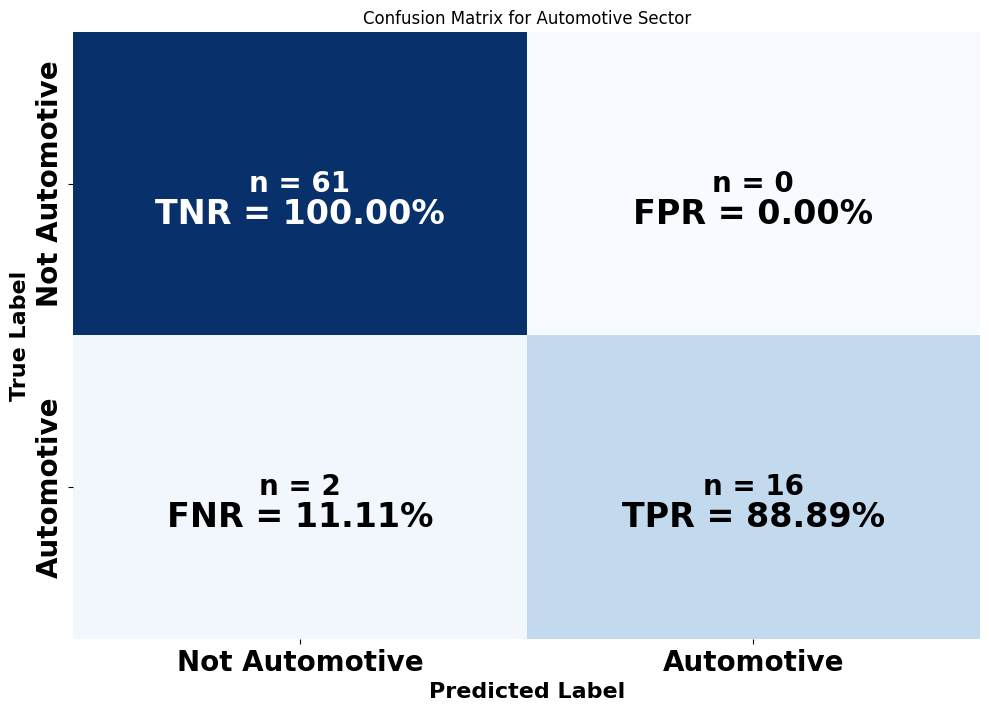


Sector: General Industrial
Accuracy: 0.9114
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.95        64
           1       0.90      0.60      0.72        15

    accuracy                           0.91        79
   macro avg       0.91      0.79      0.83        79
weighted avg       0.91      0.91      0.90        79

Total number of false positives: 1
Total number of false negatives: 6
Total Accuracy: 0.91
True Positive Rate: 0.60
False Positive Rate: 0.02
True Negative Rate: 0.98
False Negative Rate: 0.40
contextual information: General Industrial


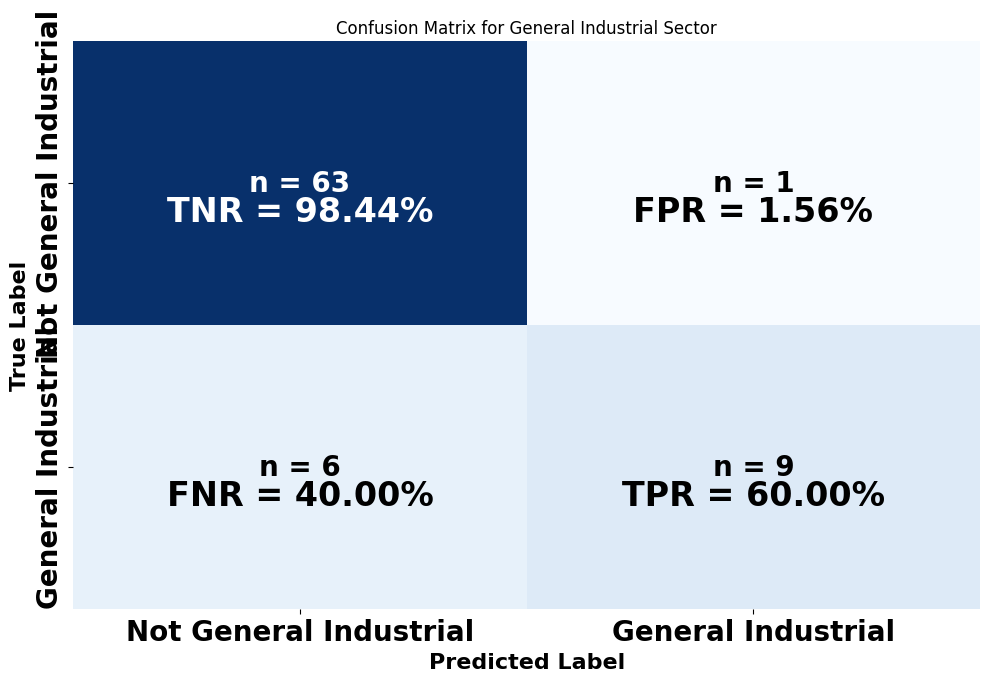


Sector: Architectural
Accuracy: 0.8861
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92        54
           1       0.83      0.80      0.82        25

    accuracy                           0.89        79
   macro avg       0.87      0.86      0.87        79
weighted avg       0.89      0.89      0.89        79

Total number of false positives: 4
Total number of false negatives: 5
Total Accuracy: 0.89
True Positive Rate: 0.80
False Positive Rate: 0.07
True Negative Rate: 0.93
False Negative Rate: 0.20
contextual information: Architectural


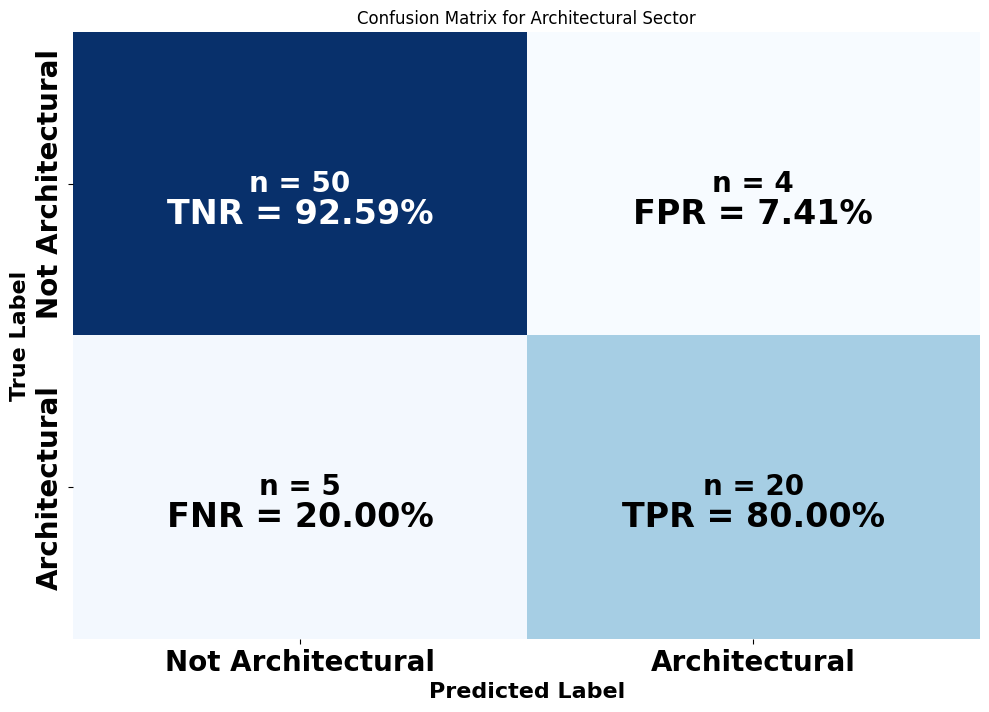


Sector: Road Marking
Accuracy: 0.9620
Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        76
           1       0.00      0.00      0.00         3

    accuracy                           0.96        79
   macro avg       0.48      0.50      0.49        79
weighted avg       0.93      0.96      0.94        79

Total number of false positives: 0
Total number of false negatives: 3
Total Accuracy: 0.96
True Positive Rate: 0.00
False Positive Rate: 0.00
True Negative Rate: 1.00
False Negative Rate: 1.00
contextual information: Road Marking


/Users/jakeford/miniconda3/envs/plopp-analysis/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/jakeford/miniconda3/envs/plopp-analysis/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/jakeford/miniconda3/envs/plopp-analysis/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

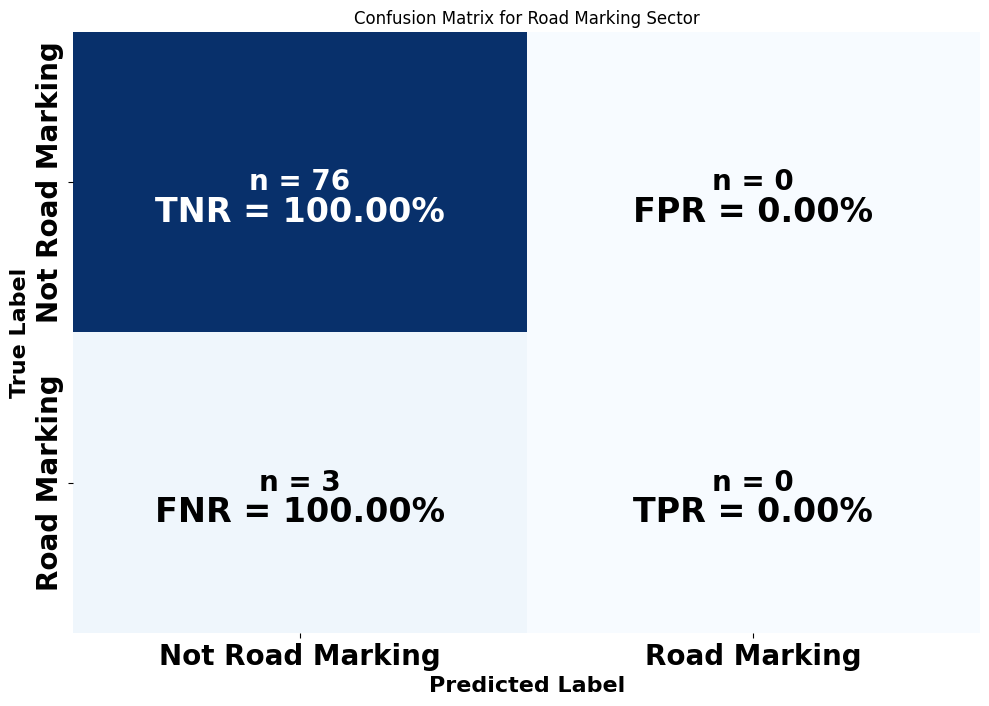


Sector: Consumer
Accuracy: 0.9367
Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        68
           1       1.00      0.55      0.71        11

    accuracy                           0.94        79
   macro avg       0.97      0.77      0.84        79
weighted avg       0.94      0.94      0.93        79

Total number of false positives: 0
Total number of false negatives: 5
Total Accuracy: 0.94
True Positive Rate: 0.55
False Positive Rate: 0.00
True Negative Rate: 1.00
False Negative Rate: 0.45
contextual information: Consumer


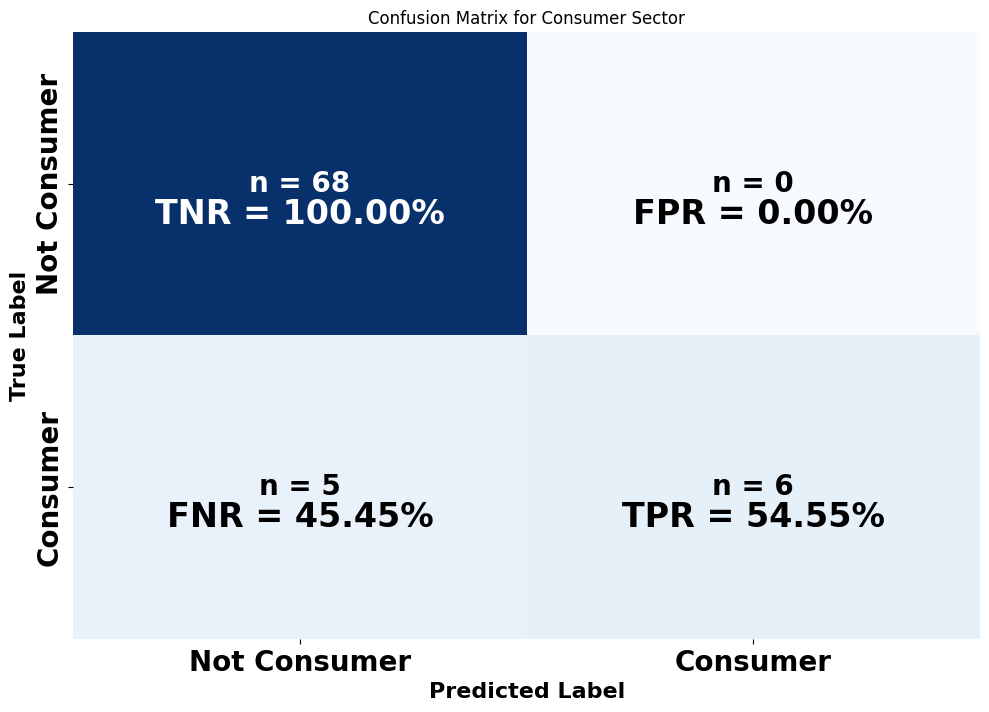


Sector: Wood
Accuracy: 0.9873
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        77
           1       1.00      0.50      0.67         2

    accuracy                           0.99        79
   macro avg       0.99      0.75      0.83        79
weighted avg       0.99      0.99      0.99        79

Total number of false positives: 0
Total number of false negatives: 1
Total Accuracy: 0.99
True Positive Rate: 0.50
False Positive Rate: 0.00
True Negative Rate: 1.00
False Negative Rate: 0.50
contextual information: Wood


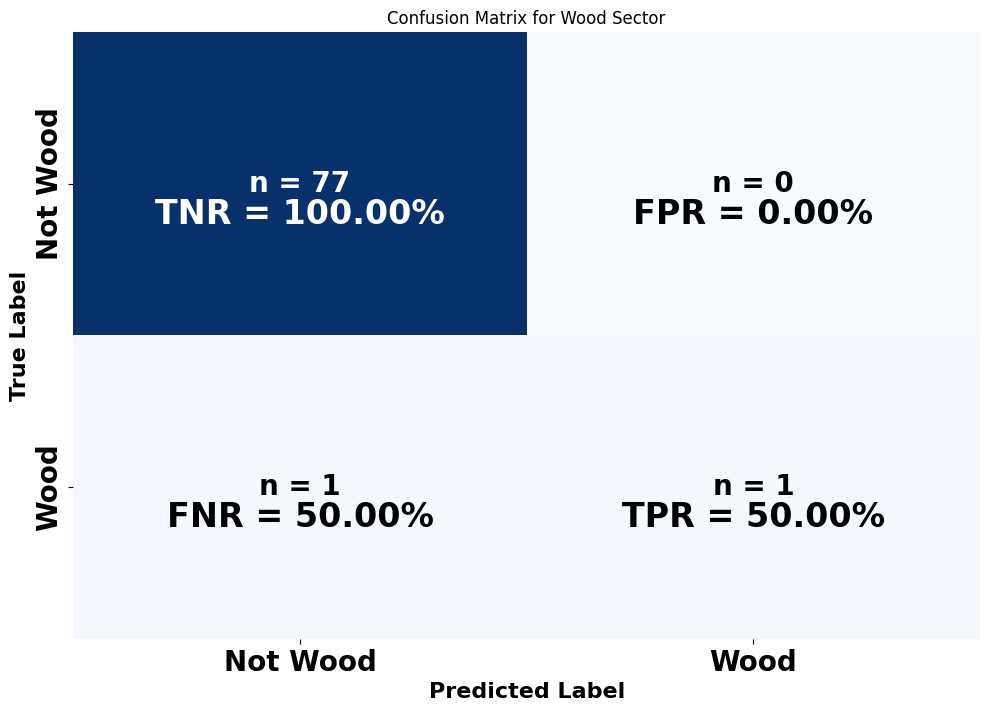


Sector: Marine
Accuracy: 0.9241
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96        74
           1       0.00      0.00      0.00         5

    accuracy                           0.92        79
   macro avg       0.47      0.49      0.48        79
weighted avg       0.88      0.92      0.90        79

Total number of false positives: 1
Total number of false negatives: 5
Total Accuracy: 0.92
True Positive Rate: 0.00
False Positive Rate: 0.01
True Negative Rate: 0.99
False Negative Rate: 1.00
contextual information: Marine


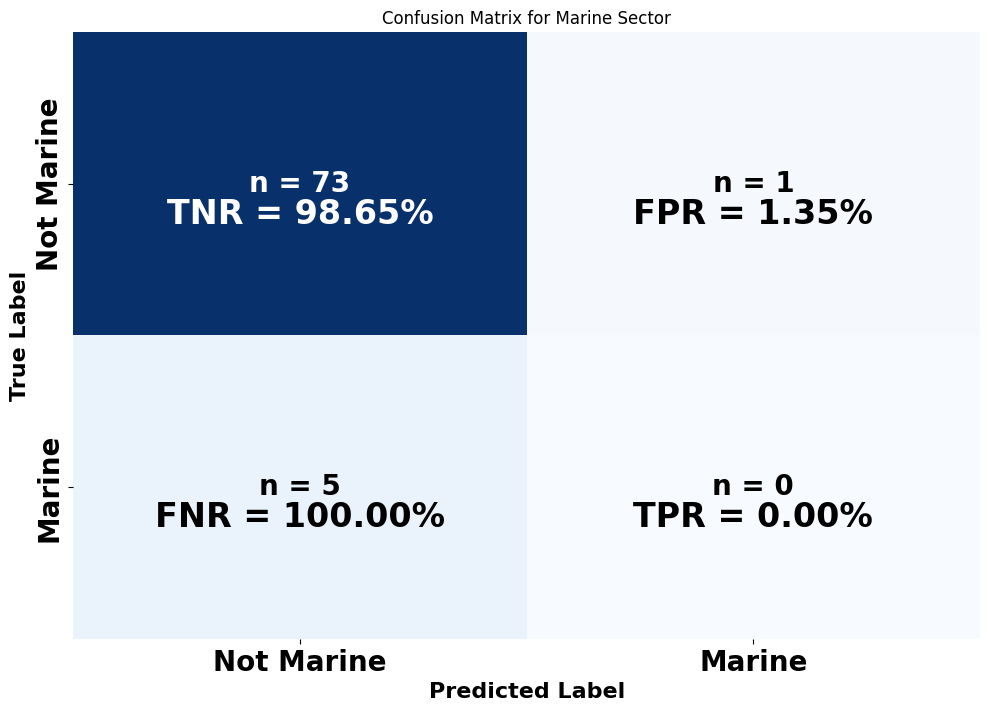

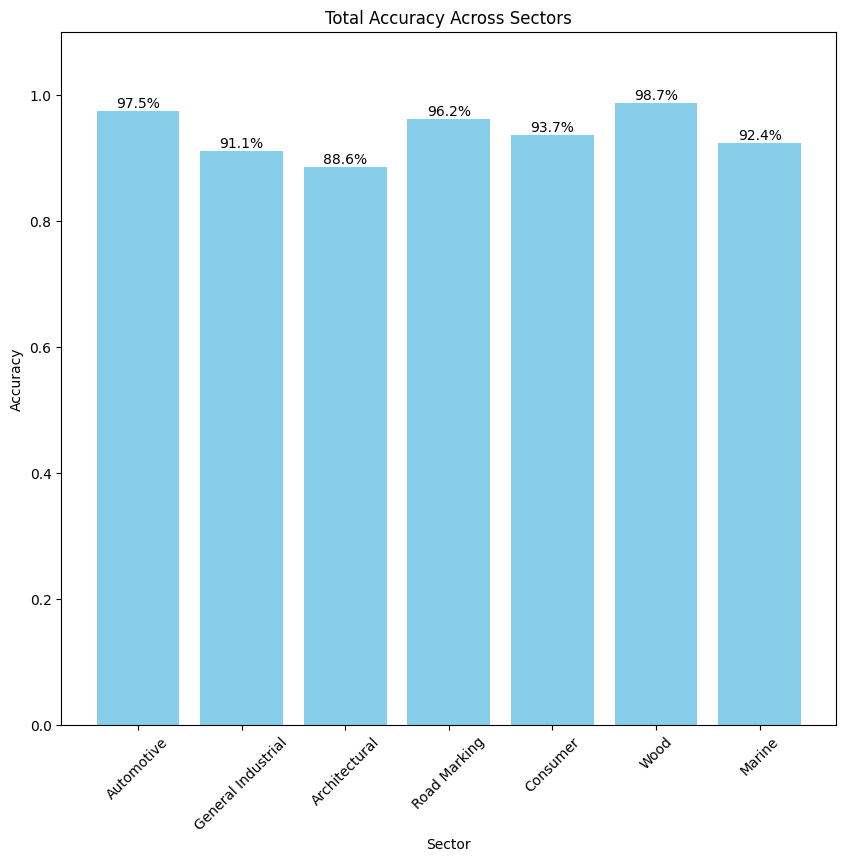


Total Accuracy across all sectors: 0.9403


In [78]:
train_with_sectors = pd.merge(train_df, add_sector_df, left_on='Sample', right_on='CSVName', how='left')

print(train_with_sectors.shape)

train_with_sectors.head()

train_with_sectors.Sector.value_counts()

# rename anytome train_with_sectors is Industrial Wood to just Wood
train_with_sectors['Sector'] = train_with_sectors['Sector'].replace('Industrial Wood', 'Wood')

# Prepare features and labels
X = train_with_sectors.drop(columns=['Sector', 'Target', 'Sample_x', 'Sample_y', 'Sample_Number', 'Color', 'CSVName', 'Group'])  # Drop unnecessary columns
y = train_with_sectors['Sector']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the pipeline
sector_pipeline = Pipeline([
    ('snv', SNVTransformer(use_scaling=True)),                # Apply SNV transformation
    ('derivative', DerivativeTransformer(deriv=1)),           # Apply derivative transformation
    ('pca', PCA(n_components=0.95)),                          # Apply PCA to retain 95% variance
    ('classifier', RandomForestClassifier(random_state=42))   # A RandomForest model
])

best_params = {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'derivatives__deriv': 1, 'snv__use_scaling': True}


# Train the pipeline
sector_pipeline.fit(X_train, y_train)

# Predictions and evaluation
y_pred = sector_pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Optionally, analyze the PCA component contributions as in your previous code
pca = sector_pipeline.named_steps['pca']
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of components that account for 95% of the variance: {n_components_95}")

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import pandas as pd

# Define a function to prepare binary labels for a specific sector
def prepare_binary_labels(data, target_sector):
    # Label the target sector as 1, all others as 0
    data['SectorBinary'] = (data['Sector'] == target_sector).astype(int)
    return data




# Define a function to train and evaluate a model for each sector
def train_sector_model(data, target_sector):
    # Prepare the binary labels
    data = prepare_binary_labels(data, target_sector)
    
    # Prepare features and binary labels
    X = data.drop(columns=['Sector', 'Target', 'Sample_x', 'Sample_y', 'Sample_Number', 'Color', 'CSVName', 'SectorBinary', 'Group'])  # Adjust as needed
    y = data['SectorBinary']
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # Define the pipeline
    sector_pipeline = Pipeline([
        ('snv', SNVTransformer(use_scaling=True)),                # Apply SNV transformation
        ('derivative', DerivativeTransformer(deriv=1)),           # Apply derivative transformation
        ('pca', PCA(n_components=0.95)),                          # Apply PCA to retain 95% variance
        ('classifier', RandomForestClassifier(random_state=42))   # A RandomForest model
    ])
    
    # Train the pipeline
    sector_pipeline.fit(X_train, y_train)
    
    # Predictions and evaluation
    y_pred = sector_pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nSector: {target_sector}")
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Calculate additional metrics
    total_accuracy = (tp + tn) / (tp + tn + fp + fn)
    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)
    tnr = tn / (tn + fp)
    fnr = fn / (fn + tp)

    print(f'Total number of false positives: {fp}')
    print(f'Total number of false negatives: {fn}')
    
    print(f'Total Accuracy: {total_accuracy:.2f}')
    print(f'True Positive Rate: {tpr:.2f}')
    print(f'False Positive Rate: {fpr:.2f}')
    print(f'True Negative Rate: {tnr:.2f}')
    print(f'False Negative Rate: {fnr:.2f}')
    
    print(f"contextual information: {target_sector}")
    
    fig, ax = plt.subplots(figsize=(10, 7))
    
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', cbar=False, 
                xticklabels=['Not ' + target_sector, target_sector], 
                yticklabels=['Not ' + target_sector, target_sector], ax=ax)   # Set annot=True to show numbers
    #ax.set_title('Random Forest Confusion Matrix')
    ax.set_xlabel('Predicted Label', fontsize=16, weight='bold')
    ax.set_ylabel('True Label', fontsize=16, weight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=20, weight='bold')
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=20, weight='bold')
    
    for i in range(2):
        for j in range(2):
            color = 'white' if (i == 0 and j == 0) else 'black'
            plt.text(j + 0.5, i + 0.5, f'n = {cm[i, j]}', ha='center', va='center', color=color, fontsize=20, weight='bold')

    plt.text(0.5, 0.6, f'TNR = {tnr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold', color='white')
    plt.text(1.5, 0.6, f'FPR = {fpr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold')
    plt.text(.5, 1.6, f'FNR = {fnr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold')
    plt.text(1.5, 1.6, f'TPR = {tpr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold', color='black')
    plt.tight_layout()
        
    # Plot and save the confusion matrix
   # plt.figure(figsize=(6, 4))
   # sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=['Not ' + target_sector, target_sector], yticklabels=['Not ' + target_sector, target_sector])
#    plt.xlabel("Predicted")
 #   plt.ylabel("Actual")
    plt.title(f"Confusion Matrix for {target_sector} Sector")
    
    # Save confusion matrix as an image file
    plt.savefig(f'../../../../Manuscript/Figures/Supplemental Paint by Sector Figures/Confusion matrix for {target_sector}.png')
    plt.show()
    
    return accuracy

# Load and prepare data (assuming train_with_sectors is already prepared and merged as before)
target_sectors = ['Automotive', 'General Industrial', 'Architectural', 
                  'Road Marking', 'Consumer', 'Wood', 'Marine']

# Initialize a list to store accuracies for each sector
accuracies = []

# Train and evaluate model for each sector
for sector in target_sectors:
    accuracy = train_sector_model(train_with_sectors.copy(), sector)
    accuracies.append(accuracy)
    

plt.figure(figsize=(10, 9))
bars = plt.bar(target_sectors, accuracies, color='skyblue')
plt.xlabel("Sector")
plt.ylabel("Accuracy")
plt.title("Total Accuracy Across Sectors")
plt.xticks(rotation=45)
plt.ylim(0, 1.1)  # Set y-axis to a scale of 0 to 1 for percentage interpretation

# Add percentage labels on top of each bar
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{acc * 100:.1f}%", 
             ha='center', va='bottom')

# Save the plot as an image file
#plt.savefig("total_accuracy_across_sectors.png")
plt.savefig(f'../../../../Manuscript/Figures/Supplemental Paint by Sector Figures/Total Accuracy for Sectors.png')

plt.show()

# Calculate and print overall mean accuracy across all sectors
total_accuracy = np.mean([acc for acc in accuracies if acc is not None])
print(f"\nTotal Accuracy across all sectors: {total_accuracy:.4f}")




# 5. Ground Truthing

Andrew Turner Data + The Citadel Data

## Andrew Turner Data

In [79]:
# load data

def process_csv_files(directory):
    data_frames = []

    for filename in os.listdir(directory):
        # add logic if filename has 'samplekey' in title, skip
        if filename != 'SampleKey.csv' and filename != 'merged' and filename.endswith('.CSV'):
            file_path = os.path.join(directory, filename) 

            df = pd.read_csv(file_path, header=None, names=['Wavelength', 'Datavalue'])
            df_transposed = df.set_index('Wavelength').T
            df_transposed['Sample'] = filename

            data_frames.append(df_transposed)

    master_df = pd.concat(data_frames, axis=0).fillna(0)

    return master_df


directory = "../../Andrew Turner data"


validate_df = process_csv_files(directory)

# remove .csv from Sample column
validate_df['Sample'] = validate_df['Sample'].str.replace('.CSV', '')

sample_key = pd.read_csv("../../Andrew Turner data/SampleKey_correct_sector.csv")

merged_df = pd.merge(validate_df, sample_key, left_on='Sample', right_on = "Mira's ID", how='left')

merged_df.columns = [int(col) if col not in ['Sample', "Mira's ID", 'Paint or non-paint','zoie_sector'] else col for col in merged_df.columns]
# rename 'Paint or non-Paint' to 'observed'
merged_df.rename(columns={"Paint or non-paint": "observed"}, inplace=True)
merged_df.drop(["Mira's ID"], axis=1, inplace=True) 

merged_df['observed'] = merged_df['observed'].map({'Non-paint': 'FLoPP', 'Paint': 'PLoPP'})

#merged_df.to_csv('../../Andrew Turner data/merged_validation_data.csv')

# 11.11.24 - drop when Sample = MP_ID_5 from sample 
merged_df = merged_df.drop(merged_df[merged_df['Sample'] == 'MP_ID_5'].index)

andrew_turner_df = merged_df
print(merged_df.shape)
merged_df.head()



(38, 939)


,397,401,404,408,412,416,420,424,428,431,...,3980,3984,3988,3992,3995,3999,4003,Sample,observed,zoie_sector
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,101.197500,101.186000,101.151200,101.145900,101.174800,101.189200,0.000000,MP_ID_23,PLoPP,General Industrial
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,101.274100,101.285100,101.336300,101.368500,101.389200,101.468100,0.000000,MP_ID_37,PLoPP,Marine
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,109.488300,109.513500,109.455400,109.437100,109.406500,109.319500,0.000000,MP_ID_36,PLoPP,Road marking
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,102.490100,102.525900,102.514200,102.469900,102.457500,102.534400,0.000000,MP_ID_22,PLoPP,Road marking
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,117.735100,117.775200,117.746500,117.706100,117.766300,117.842800,0.000000,MP_ID_34,PLoPP,Marine


## The Citadel Data

In [80]:
new_directory = "../../../../Citadel spectra samples ZD/CSV files"

def process_csv_files(directory):
    data_frames = []

    for filename in os.listdir(directory):
        # add logic if filename has 'samplekey' in title, skip
        if filename != 'SampleKey.csv' and filename != 'merged' and (filename.endswith('.csv') or filename.endswith('.CSV')):
            file_path = os.path.join(directory, filename) 

            df = pd.read_csv(file_path, header=None, names=['Wavelength', 'Datavalue'])
            df_transposed = df.set_index('Wavelength').T
            df_transposed['Sample'] = filename

            data_frames.append(df_transposed)

    master_df = pd.concat(data_frames, axis=0).fillna(0)

    return master_df
new_test = process_csv_files(new_directory)

new_test.reset_index(drop=True, inplace=True)


cols_to_keep = [col for col in merged_df.columns if col not in ['observed', 'zoie_sector']]


# Ensure new_test has the same number of columns as cols_to_keep
if len(new_test.columns) == len(cols_to_keep):
    # Assign the column names from cols_to_keep
    new_test.columns = cols_to_keep
else:
    raise ValueError(f"Number of columns in 'new_test' ({len(new_test.columns)}) does not match 'cols_to_keep' ({len(cols_to_keep)}).")



# add observed and zoie_sector

# remove .csv from end of 'Sample' column
new_test['Sample'] = new_test['Sample'].str.replace('.csv', '')




sample_key = pd.read_excel("../../../../Citadel spectra samples ZD/CSV files/2024.11.27_Citadel_sampleKey_ZoieForJake.xlsx")

sample_key = sample_key[['Sample name', 'Paint or non-paint', 'Sector']]

# rename Paint or non-paint to observed
sample_key.rename(columns={"Paint or non-paint": "observed", "Sector": "zoie_sector", "Sample name": "Sample"}, inplace=True)

# rename when observed is non-paint to FLoPP and paint to PLoPP
sample_key['observed'] = sample_key['observed'].map({'Non-paint': 'FLoPP', 'Paint': 'PLoPP'})
sample_key.head()
temp_merge = pd.merge(new_test, sample_key, left_on='Sample', right_on = "Sample", how='left')

print(temp_merge.shape)
temp_merge.head()

(49, 939)


,397,401,404,408,412,416,420,424,428,431,...,3980,3984,3988,3992,3995,3999,4003,Sample,observed,zoie_sector
0,0.000000,0.027907,0.042225,0.056918,0.040262,0.039982,0.058222,0.057476,0.049745,0.042768,...,-0.013017,-0.013120,-0.013231,-0.013156,-0.012983,-0.012962,0.000000,HA.T1.T2.N,PLoPP,Road marking
1,0.000000,0.085030,-0.001650,0.003918,0.000894,-0.036234,-0.010172,-0.000572,-0.009684,-0.005106,...,0.000626,0.001248,0.001192,0.000866,0.000862,0.001126,0.000000,RR.T1.M1.N,PLoPP,Road marking
2,0.000000,-0.063388,-0.052320,-0.022843,-0.028742,-0.034601,-0.037065,-0.034688,-0.022740,-0.015345,...,-0.008648,-0.008599,-0.008542,-0.008711,-0.008672,-0.008526,0.000000,LD.T4.T4.N,FLoPP,NaN
3,0.000000,0.028998,0.072479,0.062337,0.058387,0.052680,0.007628,0.031624,0.037149,0.025380,...,-0.000036,-0.000108,-0.000343,-0.000426,-0.000318,-0.000358,0.000000,HA.T1.R1.N,PLoPP,Road marking
4,0.000000,0.105124,-0.008674,-0.029050,0.016582,0.001171,-0.016837,-0.012092,-0.016133,-0.008505,...,-0.022028,-0.022261,-0.022012,-0.021710,-0.021796,-0.021977,0.000000,JS.T2.T2.S,PLoPP,Road marking


## Merged (Andrew Turner + The Citadel)

In [81]:
total_merged = pd.concat([merged_df, temp_merge], axis=0)
# rename 'Industrial Wood' in zoie_sector to 'Wood'
total_merged['zoie_sector'] = total_merged['zoie_sector'].replace('Industrial Wood', 'Wood')
total_merged['zoie_sector'] = total_merged['zoie_sector'].replace('Road marking', 'Road Marking')
total_merged = total_merged.dropna(subset=['observed'])

total_merged.shape



(85, 939)

In [82]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


X_val = total_merged.drop(['Sample', 'zoie_sector', 'observed'], axis=1)
y_val = total_merged['observed']


# Ensure `y_val` and `y_pred` are NumPy arrays with the same dtype
y_val_np = y_val.to_numpy(dtype='<U5')  # Convert y_val to NumPy array with the same dtype as y_pred

# Predict probabilities for each class
y_pred_proba = plopp_pipeline.predict_proba(X_val)

# Apply a cutoff of 0.60 for the positive class ('PLoPP')
y_pred = plopp_pipeline.predict(X_val)
#y_pred = np.where(y_pred_proba[:, 1] >= 0.60, 'PLoPP', 'FLoPP')

# Calculate metrics
accuracy = accuracy_score(y_val_np, y_pred)
precision = precision_score(y_val_np, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_val_np, y_pred,average='weighted', zero_division=0)
f1 = f1_score(y_val_np, y_pred, average='weighted', zero_division=0)

# # Print the results
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

cm = confusion_matrix(y_val_np, y_pred)
print("Confusion Matrix:\n", cm)

if cm.shape == (2, 2):  # Binary classification
    tn, fp, fn, tp = cm.ravel()

    total_accuracy = (tp + tn) / (tp + tn + fp + fn)
    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)
    tnr = tn / (tn + fp)
    fnr = fn / (fn + tp)

    print(f'Total Accuracy: {total_accuracy:.2f}')
    print(f'True Positive Rate: {tpr:.2f}')
    print(f'False Positive Rate: {fpr:.2f}')
    print(f'True Negative Rate: {tnr:.2f}')
    print(f'False Negative Rate: {fnr:.2f}')

Accuracy: 0.5411764705882353
Precision: 0.7907308377896612
Recall: 0.5411764705882353
F1 Score: 0.5637151702786377
Confusion Matrix:
 [[18  2]
 [37 28]]
Total Accuracy: 0.54
True Positive Rate: 0.43
False Positive Rate: 0.10
True Negative Rate: 0.90
False Negative Rate: 0.57


## Paint by Sector (Ground Truthing)

In [83]:
ground_truth_sector_df = total_merged[total_merged.observed=='PLoPP']


Evaluating sector: General Industrial

Sector: General Industrial
Accuracy: 0.8615
True Positive Rate (TPR): 0.1429
False Positive Rate (FPR): 0.0517
True Negative Rate (TNR): 0.9483
False Negative Rate (FNR): 0.8571
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92        58
           1       0.25      0.14      0.18         7

    accuracy                           0.86        65
   macro avg       0.58      0.55      0.55        65
weighted avg       0.83      0.86      0.84        65



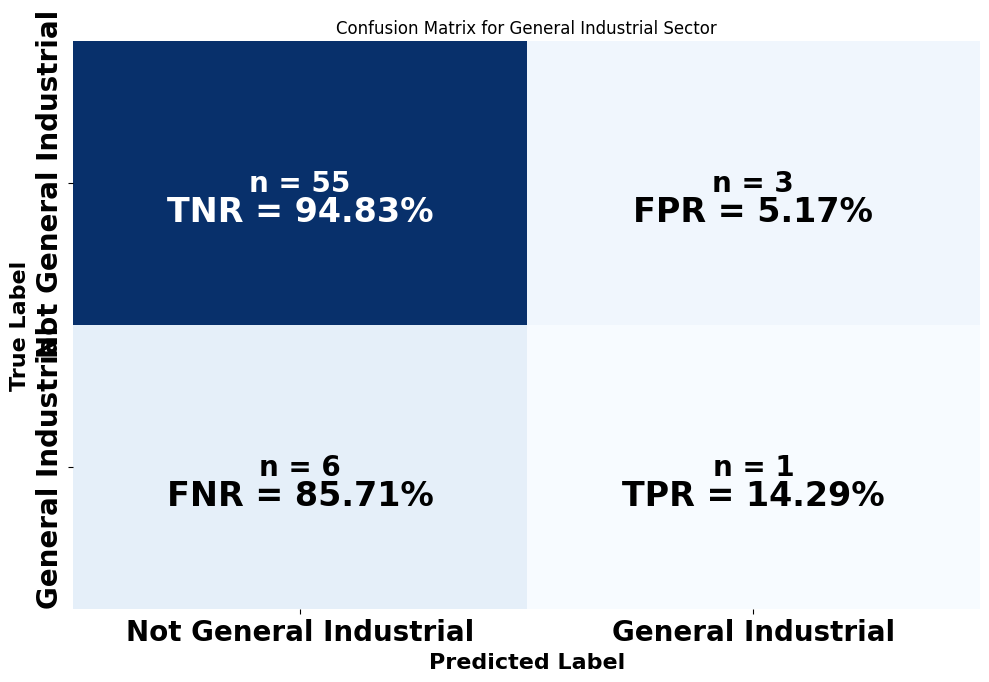

Evaluating sector: Architectural

Sector: Architectural
Accuracy: 0.5538
True Positive Rate (TPR): 0.8750
False Positive Rate (FPR): 0.4912
True Negative Rate (TNR): 0.5088
False Negative Rate (FNR): 0.1250
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.51      0.67        57
           1       0.20      0.88      0.33         8

    accuracy                           0.55        65
   macro avg       0.58      0.69      0.50        65
weighted avg       0.87      0.55      0.62        65



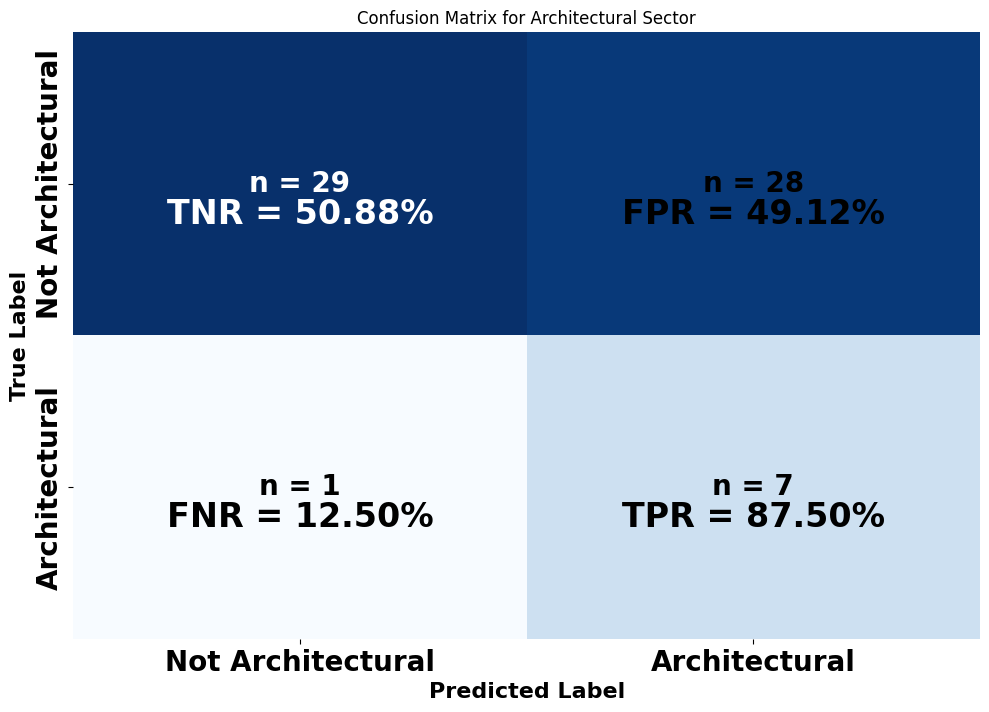

Evaluating sector: Road Marking

Sector: Road Marking
Accuracy: 0.3846
True Positive Rate (TPR): 0.0000
False Positive Rate (FPR): 0.0000
True Negative Rate (TNR): 1.0000
False Negative Rate (FNR): 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       0.38      1.00      0.56        25
           1       0.00      0.00      0.00        40

    accuracy                           0.38        65
   macro avg       0.19      0.50      0.28        65
weighted avg       0.15      0.38      0.21        65



/Users/jakeford/miniconda3/envs/plopp-analysis/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/jakeford/miniconda3/envs/plopp-analysis/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/jakeford/miniconda3/envs/plopp-analysis/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

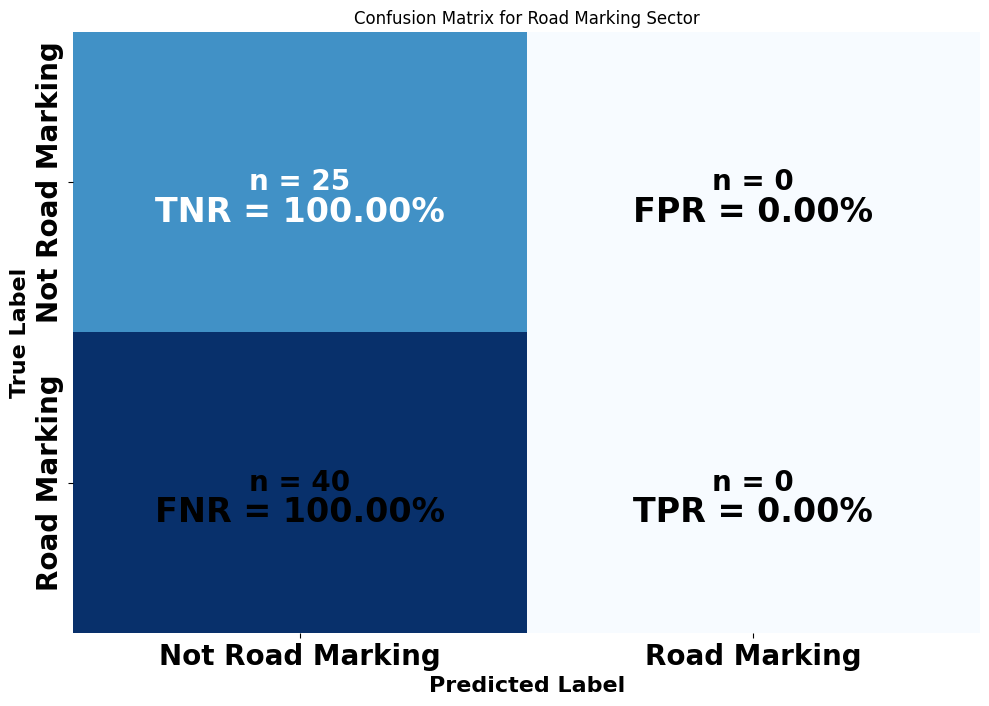

Evaluating sector: Marine

Sector: Marine
Accuracy: 0.5692
True Positive Rate (TPR): 0.0000
False Positive Rate (FPR): 0.3393
True Negative Rate (TNR): 0.6607
False Negative Rate (FNR): 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.66      0.73        56
           1       0.00      0.00      0.00         9

    accuracy                           0.57        65
   macro avg       0.40      0.33      0.36        65
weighted avg       0.69      0.57      0.63        65



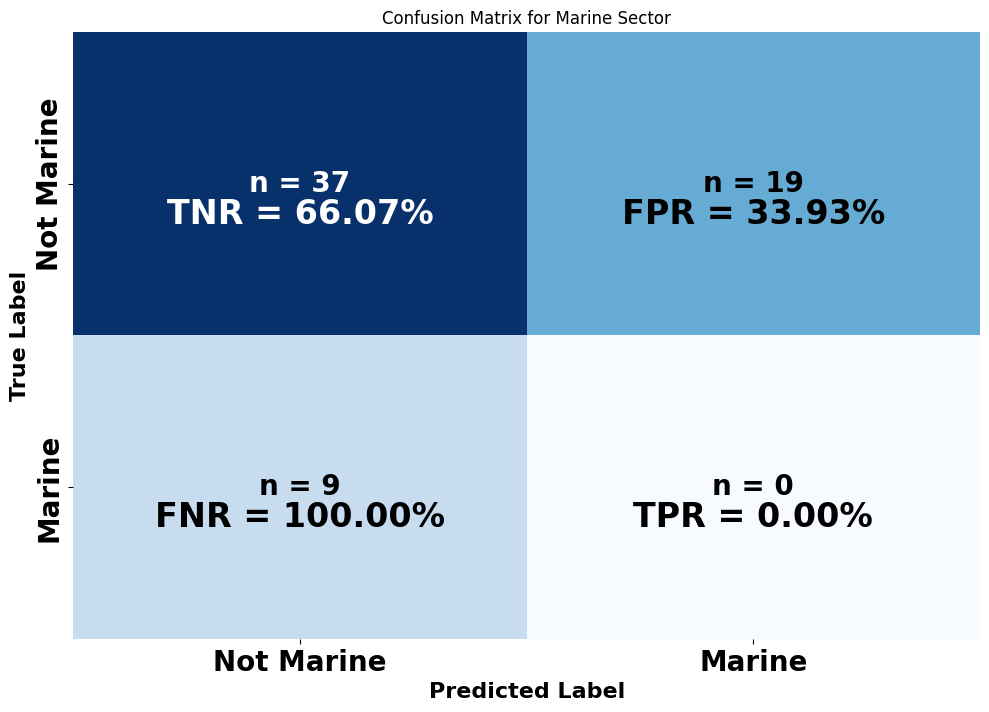

Evaluating sector: Wood

Sector: Wood
Accuracy: 0.9846
True Positive Rate (TPR): 0.0000
False Positive Rate (FPR): 0.0000
True Negative Rate (TNR): 1.0000
False Negative Rate (FNR): 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        64
           1       0.00      0.00      0.00         1

    accuracy                           0.98        65
   macro avg       0.49      0.50      0.50        65
weighted avg       0.97      0.98      0.98        65



/Users/jakeford/miniconda3/envs/plopp-analysis/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/jakeford/miniconda3/envs/plopp-analysis/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/jakeford/miniconda3/envs/plopp-analysis/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

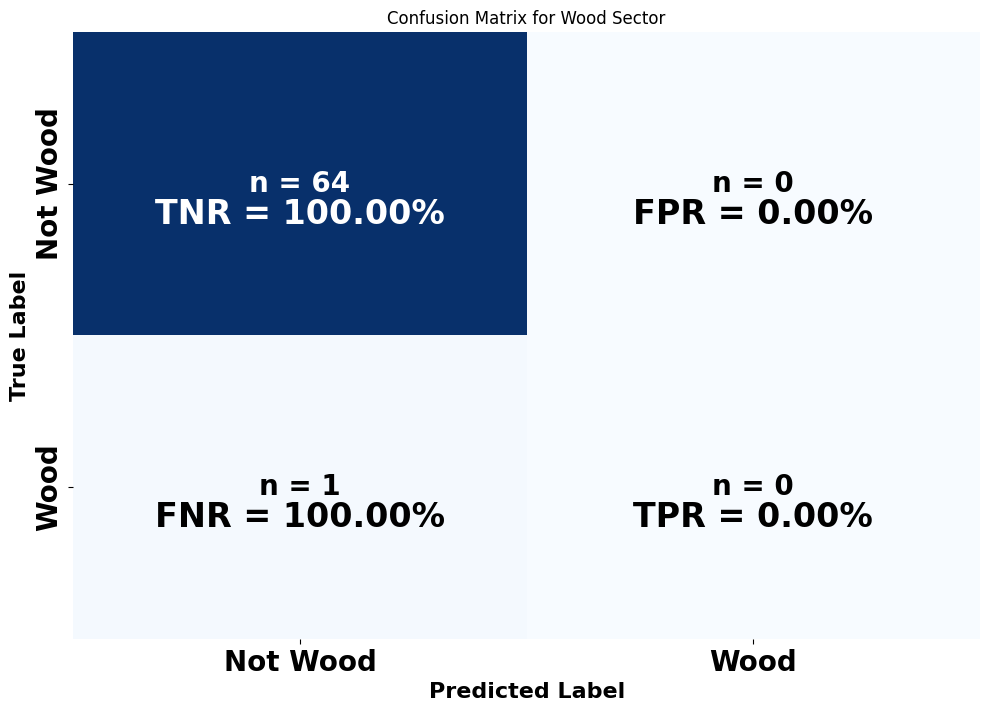


Overall Accuracy for total_merged: 0.6708


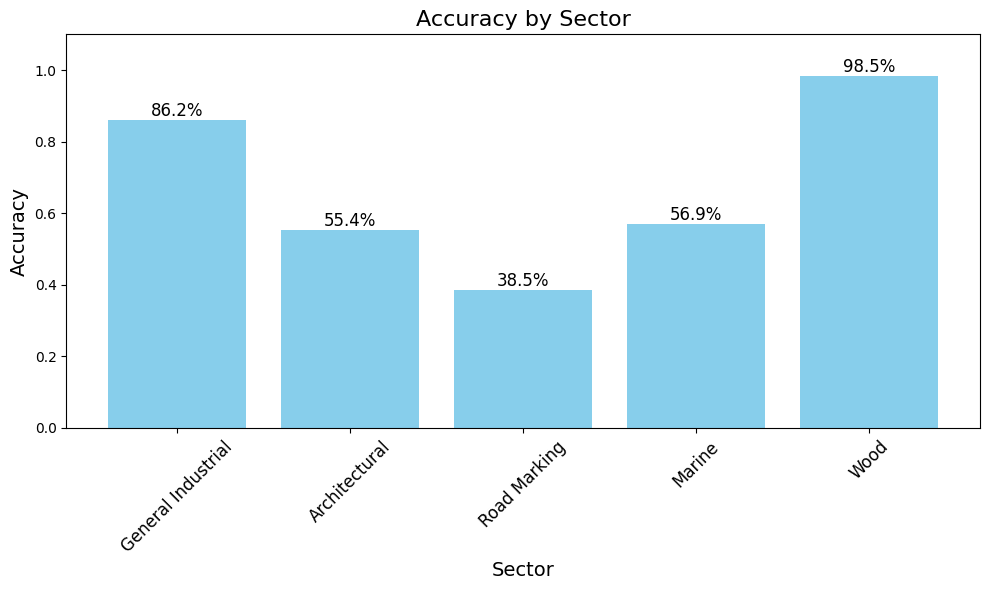

In [87]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluate_existing_model(data, target_sector, sector_pipeline):
    # Prepare binary labels for evaluation
    data['SectorBinary'] = (data['zoie_sector'] == target_sector).astype(int)
    
    # Prepare features (exclude non-feature columns)
    X = data.drop(columns=['zoie_sector', 'observed', 'Sample', 'SectorBinary'], errors='ignore')
    y = data['SectorBinary']  # True labels (binary: 1 for target sector, 0 otherwise)
    
    # Use the pipeline to predict probabilities and classes
    y_pred = sector_pipeline.predict(X)
    
    # Map predictions to binary labels for the target sector
    y_pred_binary = [1 if pred == target_sector else 0 for pred in y_pred]
    
    y_proba = sector_pipeline.predict_proba(X)[:, 1]  # Probabilities for the positive class
    
    # Compute metrics
    accuracy = accuracy_score(y, y_pred_binary)
    cm = confusion_matrix(y, y_pred_binary)
    
    # Extract values from confusion matrix
    tn, fp, fn, tp = cm.ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0  # True Positive Rate (Sensitivity)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0  # True Negative Rate (Specificity)
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0  # False Negative Rate
    
    print(f"\nSector: {target_sector}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"True Positive Rate (TPR): {tpr:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")
    print(f"True Negative Rate (TNR): {tnr:.4f}")
    print(f"False Negative Rate (FNR): {fnr:.4f}")
    print("Classification Report:")
    print(classification_report(y, y_pred_binary))
    
    # # Plot confusion matrix
    # plt.figure(figsize=(8, 6))
    # sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    #             xticklabels=['Not ' + target_sector, target_sector], 
    #             yticklabels=['Not ' + target_sector, target_sector])
    # plt.title(f"Confusion Matrix for {target_sector} Sector")
    # plt.xlabel("Predicted Label")
    # plt.ylabel("True Label")

    fig, ax = plt.subplots(figsize=(10, 7))
    
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', cbar=False, 
                xticklabels=['Not ' + target_sector, target_sector], 
                yticklabels=['Not ' + target_sector, target_sector], ax=ax)   # Set annot=True to show numbers
    #ax.set_title('Random Forest Confusion Matrix')
    ax.set_xlabel('Predicted Label', fontsize=16, weight='bold')
    ax.set_ylabel('True Label', fontsize=16, weight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=20, weight='bold')
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=20, weight='bold')
    
    for i in range(2):
        for j in range(2):
            color = 'white' if (i == 0 and j == 0) else 'black'
            plt.text(j + 0.5, i + 0.5, f'n = {cm[i, j]}', ha='center', va='center', color=color, fontsize=20, weight='bold')

    plt.text(0.5, 0.6, f'TNR = {tnr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold', color='white')
    plt.text(1.5, 0.6, f'FPR = {fpr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold')
    plt.text(.5, 1.6, f'FNR = {fnr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold')
    plt.text(1.5, 1.6, f'TPR = {tpr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold', color='black')
    plt.tight_layout()
        
    # Plot and save the confusion matrix
   # plt.figure(figsize=(6, 4))
   # sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=['Not ' + target_sector, target_sector], yticklabels=['Not ' + target_sector, target_sector])
#    plt.xlabel("Predicted")
 #   plt.ylabel("Actual")
    plt.title(f"Confusion Matrix for {target_sector} Sector")

    #plt.savefig(f'../../../../Manuscript/Figures/Supplemental Ground Truthing by Sector/Total Accuracy for Sectors.png')
    plt.savefig(f'../../../../Manuscript/Figures/Supplemental Ground Truthing by Sector/Confusion matrix for {target_sector}.png')

    plt.show()
    
    return accuracy, y_proba


# Evaluate the pipeline for all sectors in total_merged
target_sectors = ['General Industrial', 'Architectural', 'Road Marking', 'Marine', 'Wood']
accuracies = {}
probabilities = {}

for sector in target_sectors:
    print(f"Evaluating sector: {sector}")
    # Use the trained pipeline to evaluate the current sector
    accuracy, y_proba = evaluate_existing_model(ground_truth_sector_df.copy(), sector, sector_pipeline)
    accuracies[sector] = accuracy
    probabilities[sector] = y_proba  # Store probabilities for further analysis

# Print overall results
overall_accuracy = np.mean(list(accuracies.values()))
print(f"\nOverall Accuracy for total_merged: {overall_accuracy:.4f}")

# Creating the bar chart based on the `accuracies` dictionary from the evaluation loop
sectors = list(accuracies.keys())
accuracy_values = list(accuracies.values())

plt.figure(figsize=(10, 6))
bars = plt.bar(sectors, accuracy_values, color='skyblue')
plt.xlabel("Sector", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.title("Accuracy by Sector", fontsize=16)
plt.ylim(0, 1.1)  # Accuracy ranges from 0 to 1

# Annotate the bars with accuracy values
for bar, acc in zip(bars, accuracy_values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"{acc * 100:.1f}%", ha='center', va='bottom', fontsize=12)

plt.xticks(rotation=45, fontsize=12)
plt.tight_layout()

plt.savefig(f'../../../../Manuscript/Figures/Supplemental Ground Truthing by Sector/Total Accuracy for Sectors.png')

plt.show()
